In [43]:
#1.Implementation of Fuzzy Set Operations (Union, Intersection, and Complement) using Python and NumPy
import numpy as np

def fuzzy_union_or(A, B, operator='max'):
    if len(A) != len(B):
        raise ValueError("Fuzzy sets must have the same length (same universe of discourse).")
    if operator == 'max':
        return np.maximum(A, B)
    else:
        raise NotImplementedError(f"Operator '{operator}' not supported for Fuzzy Union.")

def fuzzy_intersection_and(A, B, operator='min'):
    if len(A) != len(B):
        raise ValueError("Fuzzy sets must have the same length (same universe of discourse).")
    if operator == 'min':
        return np.minimum(A, B)
    else:
        raise NotImplementedError(f"Operator '{operator}' not supported for Fuzzy Intersection.")

def fuzzy_complement_not(A):
    return 1 - A

U = np.array([1, 2, 3, 4, 5])
print(f"Universe of Discourse (U): {U}\n")

A = np.array([1.0, 0.8, 0.4, 0.1, 0.0])
B = np.array([0.0, 0.1, 0.3, 0.7, 1.0])

print("--- Original Sets ---")
print(f"Fuzzy Set A: {A}")
print(f"Fuzzy Set B: {B}\n")

# a. Fuzzy UNION (OR)
A_OR_B = fuzzy_union_or(A, B)
print("--- Fuzzy UNION (A OR B) ---")
print(f"Operation: max(mu_A(x), mu_B(x))")
print(f"Result (A OR B): {A_OR_B}\n")
# b. Fuzzy INTERSECTION (AND)
A_AND_B = fuzzy_intersection_and(A, B)
print("--- Fuzzy INTERSECTION (A AND B) ---")
print(f"Operation: min(mu_A(x), mu_B(x))")
print(f"Result (A AND B): {A_AND_B}\n")
# c. Fuzzy COMPLEMENT (NOT)
NOT_A = fuzzy_complement_not(A)
print("--- Fuzzy COMPLEMENT (NOT A) ---")
print(f"Operation: 1 - mu_A(x)")
print(f"Result (NOT A): {NOT_A}\n")
NOT_B = fuzzy_complement_not(B)
print("--- Fuzzy COMPLEMENT (NOT B) ---")
print(f"Operation: 1 - mu_B(x)")
print(f"Result (NOT B): {NOT_B}")


Universe of Discourse (U): [1 2 3 4 5]

--- Original Sets ---
Fuzzy Set A: [1.  0.8 0.4 0.1 0. ]
Fuzzy Set B: [0.  0.1 0.3 0.7 1. ]

--- Fuzzy UNION (A OR B) ---
Operation: max(mu_A(x), mu_B(x))
Result (A OR B): [1.  0.8 0.4 0.7 1. ]

--- Fuzzy INTERSECTION (A AND B) ---
Operation: min(mu_A(x), mu_B(x))
Result (A AND B): [0.  0.1 0.3 0.1 0. ]

--- Fuzzy COMPLEMENT (NOT A) ---
Operation: 1 - mu_A(x)
Result (NOT A): [0.  0.2 0.6 0.9 1. ]

--- Fuzzy COMPLEMENT (NOT B) ---
Operation: 1 - mu_B(x)
Result (NOT B): [1.  0.9 0.7 0.3 0. ]


After installing `scikit-fuzzy`, please re-run the cells that were giving the `ModuleNotFoundError` to ensure the fix has been applied.

Service Rating: 6.5/10
Food Rating: 9.8/10
*** Recommended Tip: 13.16% ***


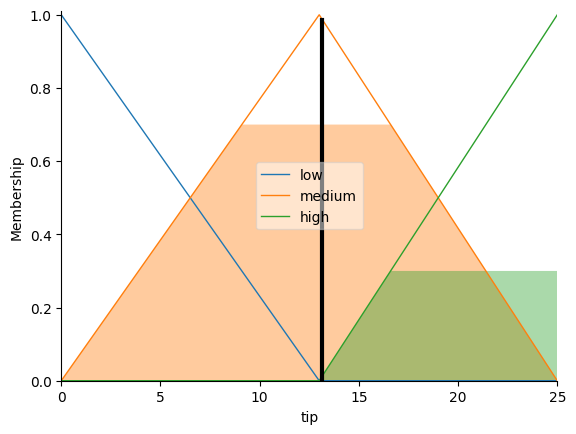


--- Example 2: Poor Service/Bad Food ---
Recommended Tip: 10.66%


In [42]:
#2. Design of Fuzzy Inference System (FIS)

import numpy as np
!pip install scikit-fuzzy
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')
food = ctrl.Antecedent(np.arange(0, 11, 1), 'food')
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')
service['poor'] = fuzz.trimf(service.universe, [0, 0, 5])
service['acceptable'] = fuzz.trimf(service.universe, [0, 5, 10])
service['excellent'] = fuzz.trimf(service.universe, [5, 10, 10])
food['bad'] = fuzz.trapmf(food.universe, [0, 0, 1, 3])
food['decent'] = fuzz.trimf(food.universe, [1, 5, 9])
food['great'] = fuzz.trapmf(food.universe, [7, 9, 10, 10])
tip['low'] = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high'] = fuzz.trimf(tip.universe, [13, 25, 25])
rule1 = ctrl.Rule(service['poor'] | food['bad'], tip['low'])
rule2 = ctrl.Rule(service['acceptable'], tip['medium'])
rule3 = ctrl.Rule(service['excellent'] & food['great'], tip['high'])
rule4 = ctrl.Rule(food['decent'] & service['poor'], tip['medium'])
tip_control = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
tipping_simulation = ctrl.ControlSystemSimulation(tip_control)
tipping_simulation.input['service'] = 6.5
tipping_simulation.input['food'] = 9.8
tipping_simulation.compute()
tip_amount = tipping_simulation.output['tip']
print(f"Service Rating: 6.5/10")
print(f"Food Rating: 9.8/10")
print(f"*** Recommended Tip: {tip_amount:.2f}% ***")
tip.view(sim=tipping_simulation)
plt.show()
print("\n--- Example 2: Poor Service/Bad Food ---")
tipping_simulation.input['service'] = 2
tipping_simulation.input['food'] = 3
tipping_simulation.compute()
print(f"Recommended Tip: {tipping_simulation.output['tip']:.2f}%")

--- Defuzzification Results ---
Centroid (CoG):        12.4075
Bisector (BoA):        13.4457
Mean of Maximum (MoM): 15.0000
Smallest of Max (SoM): 15.0000
Largest of Max (LoM):  15.0000


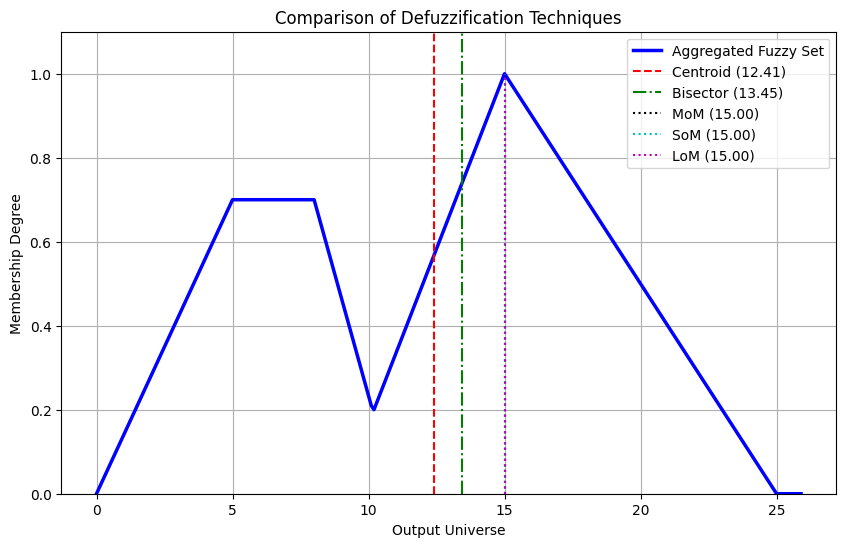

In [41]:
#3. Defuzzification Techniques
import numpy as np
!pip install scikit-fuzzy
import skfuzzy as fuzz
import matplotlib.pyplot as plt
def demonstrate_defuzzification(universe, aggregated_mf):
    """
    Applies and compares five common defuzzification techniques to a given
    aggregated membership function (MF).
    """
    cog = fuzz.defuzz(universe, aggregated_mf, 'centroid')
    boa = fuzz.defuzz(universe, aggregated_mf, 'bisector')
    mom = fuzz.defuzz(universe, aggregated_mf, 'mom')
    som = fuzz.defuzz(universe, aggregated_mf, 'som')
    lom = fuzz.defuzz(universe, aggregated_mf, 'lom')
    print("--- Defuzzification Results ---")
    print(f"Centroid (CoG):        {cog:.4f}")
    print(f"Bisector (BoA):        {boa:.4f}")
    print(f"Mean of Maximum (MoM): {mom:.4f}")
    print(f"Smallest of Max (SoM): {som:.4f}")
    print(f"Largest of Max (LoM):  {lom:.4f}")
    plt.figure(figsize=(10, 6))
    plt.plot(universe, aggregated_mf, 'b', linewidth=2.5, label='Aggregated Fuzzy Set')
    plt.axvline(cog, color='r', linestyle='--', label=f'Centroid ({cog:.2f})')
    plt.axvline(boa, color='g', linestyle='-.', label=f'Bisector ({boa:.2f})')
    plt.plot([mom, mom], [0, 1.0], 'k:', label=f'MoM ({mom:.2f})')
    plt.plot([som, som], [0, 1.0], 'c:', label=f'SoM ({som:.2f})')
    plt.plot([lom, lom], [0, 1.0], 'm:', label=f'LoM ({lom:.2f})')
    plt.title('Comparison of Defuzzification Techniques')
    plt.ylabel('Membership Degree')
    plt.xlabel('Output Universe')
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(True)
    plt.show()
X = np.arange(0, 26, 0.1)
mf_1 = fuzz.trapmf(X, [0, 5, 8, 11])
mf_2 = fuzz.trimf(X, [9, 15, 25])
aggregated_mf = np.fmax(mf_1 * 0.7, mf_2 * 1.0)
demonstrate_defuzzification(X, aggregated_mf)

--- Training Perceptron (Epochs: 50, Rate: 0.1) ---
 Converged successfully at Epoch 6.

--- Training Complete ---
Final Weights: [0.14289157 0.02324715]
Final Bias: -0.1616

--- Testing Model Predictions ---
Input: [0 0], Predicted: 0, Expected: 0 (Correct)
Input: [0 1], Predicted: 0, Expected: 0 (Correct)
Input: [1 0], Predicted: 0, Expected: 0 (Correct)
Input: [1 1], Predicted: 1, Expected: 1 (Correct)


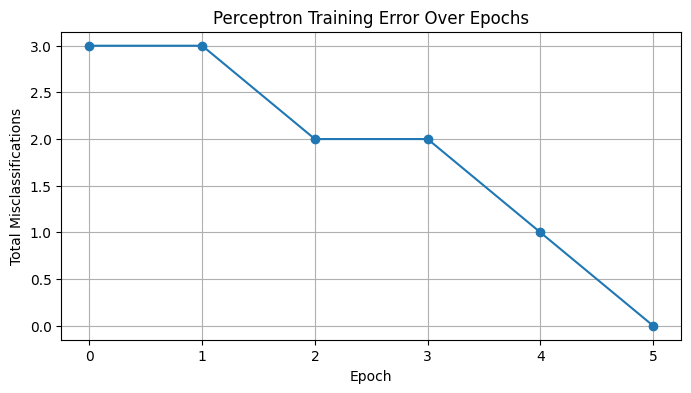

In [24]:
#4. Implementation of Single-Layer Perceptron
import numpy as np
import matplotlib.pyplot as plt
def step_function(weighted_sum):
    """
    The Perceptron uses a Heaviside step function as its activation.
    It returns 1 (activate) if the weighted sum is non-negative, else 0 (deactivate).
    """
    return 1 if weighted_sum >= 0 else 0

class Perceptron:
    """
    Implements the core learning logic of a Single-Layer Perceptron.
    """
    def __init__(self, num_inputs, learning_rate=0.1, max_epochs=100):
        self.weights = np.random.uniform(low=-0.5, high=0.5, size=num_inputs)
        self.bias = np.random.uniform(low=-0.5, high=0.5, size=1)
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.errors = []

    def predict(self, inputs):
        """
        Calculates the weighted sum and applies the step function.
        Output = step( (W . X) + b )
        """
        weighted_sum = np.dot(inputs, self.weights) + self.bias
        return step_function(weighted_sum)

    def train(self, training_inputs, labels):
        """
        Trains the perceptron using the Perceptron Learning Rule.
        Weights are updated only when a misclassification occurs.
        """
        print(f"--- Training Perceptron (Epochs: {self.max_epochs}, Rate: {self.learning_rate}) ---")
        for epoch in range(self.max_epochs):
            total_error = 0
            for inputs, label in zip(training_inputs, labels):
                prediction = self.predict(inputs)
                error = label - prediction
                total_error += abs(error)
                if error != 0:
                    self.weights += self.learning_rate * error * inputs
                    self.bias += self.learning_rate * error * 1
            self.errors.append(total_error)
            if total_error == 0:
                print(f" Converged successfully at Epoch {epoch + 1}.")
                break
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1}/{self.max_epochs}, Total Error: {total_error}")
        print("\n--- Training Complete ---")
        print(f"Final Weights: {self.weights}")
        print(f"Final Bias: {self.bias[0]:.4f}")
X_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_train = np.array([0, 0, 0, 1])
perceptron = Perceptron(num_inputs=X_train.shape[1], learning_rate=0.1, max_epochs=50)
perceptron.train(X_train, y_train)
print("\n--- Testing Model Predictions ---")
test_cases = X_train
test_labels = y_train
for inputs, expected in zip(test_cases, test_labels):
    prediction = perceptron.predict(inputs)
    status = "Correct" if prediction == expected else "Incorrect"
    print(f"Input: {inputs}, Predicted: {prediction}, Expected: {expected} ({status})")
plt.figure(figsize=(8, 4))
plt.plot(perceptron.errors, marker='o')
plt.title('Perceptron Training Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Total Misclassifications')
plt.grid(True)
plt.show()

--- Training MLP (Hidden Size: 4, Rate: 0.2) ---
Epoch 1000/10000, Mean Squared Error: 0.249254
Epoch 2000/10000, Mean Squared Error: 0.203362
Epoch 3000/10000, Mean Squared Error: 0.059984
Epoch 4000/10000, Mean Squared Error: 0.009089
Epoch 5000/10000, Mean Squared Error: 0.004031
Epoch 6000/10000, Mean Squared Error: 0.002477
Epoch 7000/10000, Mean Squared Error: 0.001756
Epoch 8000/10000, Mean Squared Error: 0.001348
Epoch 9000/10000, Mean Squared Error: 0.001088
Epoch 10000/10000, Mean Squared Error: 0.000909

--- Training Complete ---

--- Testing Model Predictions ---
Input: [0 0], Output: 0.0297, Predicted Class: 0,
Expected: 0 (Correct)
Input: [0 1], Output: 0.9697, Predicted Class: 1,
Expected: 1 (Correct)
Input: [1 0], Output: 0.9699, Predicted Class: 1,
Expected: 1 (Correct)
Input: [1 1], Output: 0.0305, Predicted Class: 0,
Expected: 0 (Correct)


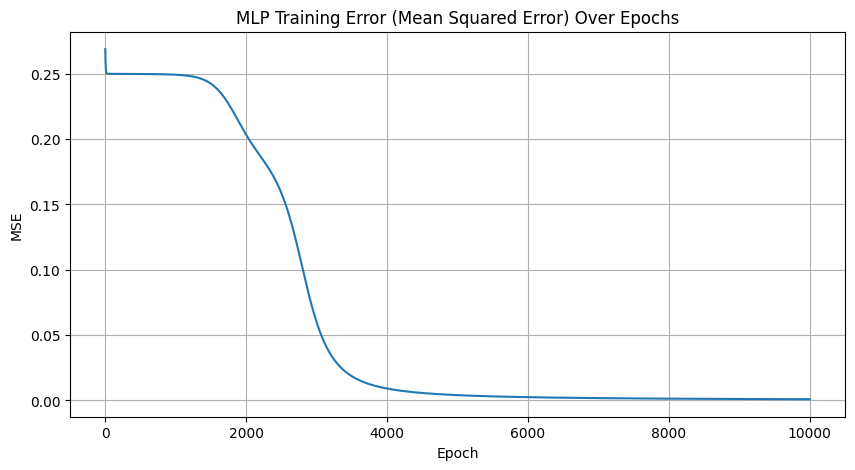

In [25]:
#5. Multilayer Perceptron using Back propagation Algorithm

import numpy as np

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(output):
    return output * (1 - output)

class MLP_Backpropagation:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1,max_epochs=10000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs

        self.W_ih = np.random.uniform(low=-0.5, high=0.5, size=(input_size, hidden_size))
        self.b_h = np.zeros((1, hidden_size))

        self.W_ho = np.random.uniform(low=-0.5, high=0.5, size=(hidden_size, output_size))
        self.b_o = np.zeros((1, output_size))

        self.errors = []

    def forward_pass(self, X):
        self.net_h = np.dot(X, self.W_ih) + self.b_h
        self.out_h = sigmoid(self.net_h)

        self.net_o = np.dot(self.out_h, self.W_ho) + self.b_o
        self.out_o = sigmoid(self.net_o)

        return self.out_o

    def backward_pass(self, X, y, out_o, out_h):
        error_o = y - out_o
        d_o = error_o * sigmoid_derivative(out_o)

        error_h = d_o.dot(self.W_ho.T)
        d_h = error_h * sigmoid_derivative(out_h)

        self.W_ho += self.out_h.T.dot(d_o) * self.learning_rate
        self.b_o += np.sum(d_o, axis=0, keepdims=True) * self.learning_rate

        self.W_ih += X.T.dot(d_h) * self.learning_rate
        self.b_h += np.sum(d_h, axis=0, keepdims=True) * self.learning_rate

        return np.mean(error_o**2)

    def train(self, X_train, y_train):
        print(f"--- Training MLP (Hidden Size: {self.hidden_size}, Rate: {self.learning_rate}) ---")

        for epoch in range(self.max_epochs):
            out_o = self.forward_pass(X_train)
            mse = self.backward_pass(X_train, y_train, out_o, self.out_h)

            self.errors.append(mse)

            if (epoch + 1) % 1000 == 0:
                print(f"Epoch {epoch + 1}/{self.max_epochs}, Mean Squared Error: {mse:.6f}")

        print("\n--- Training Complete ---")

X_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_train = np.array([
    [0],
    [1],
    [1],
    [0]
])
mlp = MLP_Backpropagation(
input_size=2,
hidden_size=4,
output_size=1,
learning_rate=0.2,
max_epochs=10000
)
mlp.train(X_train, y_train)
print("\n--- Testing Model Predictions ---")
predictions = mlp.forward_pass(X_train)
for inputs, prediction, expected in zip(X_train, predictions, y_train):
    predicted_class = 1 if prediction[0] >= 0.5 else 0
    status = "Correct" if predicted_class == expected[0] else "Incorrect"
    print(f"Input: {inputs}, Output: {prediction[0]:.4f}, Predicted Class: {predicted_class},\nExpected: {expected[0]} ({status})")
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(mlp.errors)
plt.title('MLP Training Error (Mean Squared Error) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

In [26]:
#6. Implementation of Simple Neural Network (McCulloh Pitts model)
#Implementation of Simple Neural Network (McCulloh Pitts model)

import numpy as np

def mcp_activation(net_input, threshold):
    return 1 if net_input >= threshold else 0

def mcp_neuron(inputs, weights, threshold):
    inputs = np.array(inputs)
    weights = np.array(weights)
    net_input = np.dot(inputs, weights)
    output = mcp_activation(net_input, threshold)
    return net_input, output

def implement_or_gate():
    print("\n--- Implementing Logical OR Gate ---")
    weights = [1, 1]
    threshold = 1
    test_cases = [
        ([0, 0], 0),
        ([0, 1], 1),
        ([1, 0], 1),
        ([1, 1], 1)
    ]
    print(f"Weights: {weights}, Threshold: {threshold}")
    print("Input (A, B) | Net Input | Output | Expected")
    print("-" * 38)
    for inputs, expected in test_cases:
        net_input, output = mcp_neuron(inputs, weights, threshold)
        print(f"  {inputs[0]}, {inputs[1]}    |   {net_input}      |    {output}   |   {expected}")
def implement_not_gate():
    print("\n--- Implementing Logical NOT Gate ---")
    weights = [-1]
    threshold = 0
    test_cases = [
        ([0], 1),
        ([1], 0)
    ]
    print(f"Weights: {weights}, Threshold: {threshold}")
    print("Input (A) | Net Input | Output | Expected")
    print("-" * 38)
    for inputs, expected in test_cases:
        net_input, output = mcp_neuron(inputs, weights, threshold)
        print(f"    {inputs[0]}   |    {net_input}      |    {output}   |   {expected}")
implement_or_gate()
implement_not_gate()


--- Implementing Logical OR Gate ---
Weights: [1, 1], Threshold: 1
Input (A, B) | Net Input | Output | Expected
--------------------------------------
  0, 0    |   0      |    0   |   0
  0, 1    |   1      |    1   |   1
  1, 0    |   1      |    1   |   1
  1, 1    |   2      |    1   |   1

--- Implementing Logical NOT Gate ---
Weights: [-1], Threshold: 0
Input (A) | Net Input | Output | Expected
--------------------------------------
    0   |    0      |    1   |   1
    1   |    -1      |    0   |   0


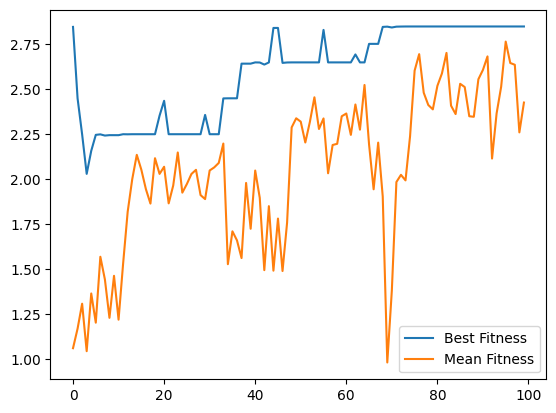

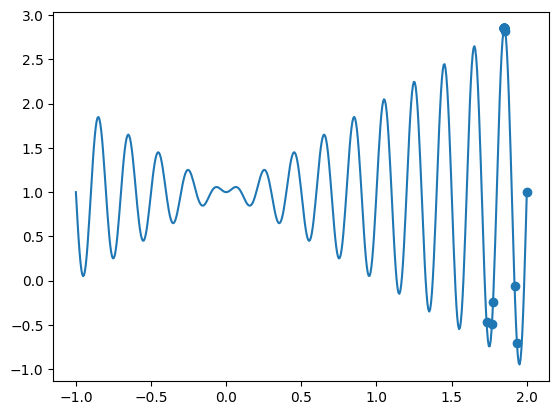

Best solution: 0.004380491912869652
Minimum value: 1.918870939871642e-05


In [27]:
#7. Implementation of Genetic Algorithm (GA)

import numpy as np
import matplotlib.pyplot as plt
def fitness_function(x):
    return x * np.sin(10 * np.pi * x) + 1
POP_SIZE = 40
GENERATIONS = 100
X_MIN, X_MAX = -1.0, 2.0
CROSSOVER_PROB = 0.9
MUTATION_PROB = 0.2
MUTATION_STD = 0.1

np.random.seed(42)
population = np.random.uniform(X_MIN, X_MAX, POP_SIZE)
def tournament_selection(pop, fitness, k=3):
    selected = []
    for _ in range(len(pop)):
        idx = np.random.choice(len(pop), k, replace=False)
        selected.append(pop[idx[np.argmax(fitness[idx])]])
    return np.array(selected)

def arithmetic_crossover(p1, p2):
    alpha = np.random.rand()
    return alpha * p1 + (1 - alpha) * p2, alpha * p2 + (1 - alpha) * p1

def mutate(x):
    if np.random.rand() < MUTATION_PROB:
        x += np.random.normal(0, MUTATION_STD)
    return np.clip(x, X_MIN, X_MAX)
best_history = []
mean_history = []
for _ in range(GENERATIONS):
    fitness = fitness_function(population)
    best_history.append(np.max(fitness))
    mean_history.append(np.mean(fitness))
    parents = tournament_selection(population, fitness)
    offspring = []
    np.random.shuffle(parents)
    for i in range(0, POP_SIZE, 2):
        if np.random.rand() < CROSSOVER_PROB:
            c1, c2 = arithmetic_crossover(parents[i], parents[i + 1])
        else:
            c1, c2 = parents[i], parents[i + 1]
        offspring.extend([mutate(c1), mutate(c2)])
    population = np.array(offspring)
x = np.linspace(X_MIN, X_MAX, 500)

plt.figure()
plt.plot(best_history, label="Best Fitness")
plt.plot(mean_history, label="Mean Fitness")
plt.legend()
plt.show()

plt.figure()
plt.plot(x, fitness_function(x))
plt.scatter(population, fitness_function(population))
plt.show()


#7 B

import random

def fitness(x):
    return x * x

def initialize_population(size):
    return [random.uniform(-10, 10) for _ in range(size)]

def selection(population):
    a, b = random.sample(population, 2)
    return a if fitness(a) < fitness(b) else b

def crossover(parent1, parent2):
    alpha = random.random()
    return alpha * parent1 + (1 - alpha) * parent2

def mutation(child, rate=0.1):
    if random.random() < rate:
        child += random.uniform(-1, 1)
    return child

def genetic_algorithm():
    population_size = 20
    generations = 50

    population = initialize_population(population_size)

    for _ in range(generations):
        new_population = []
        for _ in range(population_size):
            p1 = selection(population)
            p2 = selection(population)
            child = crossover(p1, p2)
            child = mutation(child)
            new_population.append(child)
        population = new_population

    best = min(population, key=fitness)
    print("Best solution:", best)
    print("Minimum value:", fitness(best))

genetic_algorithm()

Best tour: [1, 3, 2, 0]
Minimum distance: 80
Best Route: [0, 1, 3, 4, 2]
Minimum Distance: 26


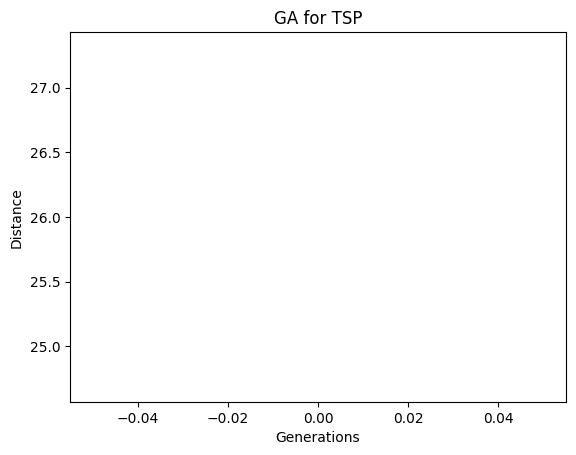

In [28]:
#8. Solving Travelling Salesman Problem using GA

import random
import numpy as np
distance = np.array([
[0, 10, 15, 20],
[10, 0, 35, 25],
[15, 35, 0, 30],
[20, 25, 30, 0]
])
NUM_CITIES = 4
POP_SIZE = 10
GENERATIONS = 100
MUTATION_RATE = 0.2
def total_distance(tour):
    return sum(distance[tour[i], tour[(i + 1) % NUM_CITIES]]
    for i in range(NUM_CITIES))
def fitness(tour):
    return 1 / total_distance(tour)
def create_population():
    return [random.sample(range(NUM_CITIES), NUM_CITIES)
    for _ in range(POP_SIZE)]
def selection(population):
    a, b = random.sample(population, 2)
    return a if fitness(a) > fitness(b) else b
def crossover(p1, p2):
    start, end = sorted(random.sample(range(NUM_CITIES), 2))
    child = [-1] * NUM_CITIES
    child[start:end] = p1[start:end]
    pointer = end
    for city in p2:
        if city not in child:
            if pointer >= NUM_CITIES:
                pointer = 0
            child[pointer] = city
            pointer += 1
    return child
def mutation(tour):
    if random.random() < MUTATION_RATE:
        i, j = random.sample(range(NUM_CITIES), 2)
        tour[i], tour[j] = tour[j], tour[i]
    return tour
population = create_population()
for _ in range(GENERATIONS):
    new_population = []
    for _ in range(POP_SIZE):
        parent1 = selection(population)
        parent2 = selection(population)
        child = crossover(parent1, parent2)
        child = mutation(child)
        new_population.append(child)
    population = new_population
best_tour = min(population, key=total_distance)
print("Best tour:", best_tour)
print("Minimum distance:", total_distance(best_tour))

#8 B.
import numpy as np
import random
import matplotlib.pyplot as plt
dist = np.array([
[0, 2, 9, 10, 7],
[2, 0, 6, 4, 3],
[9, 6, 0, 8, 5],
[10, 4, 8, 0, 6],
[7, 3, 5, 6, 0]
])
NUM_CITIES = len(dist)
POP_SIZE = 50
GENERATIONS = 200
MUTATION_RATE = 0.2
def total_distance(route):
    return sum(dist[route[i], route[i+1]] for i in range(NUM_CITIES-1)) + dist[route[-1],route[0]]
def fitness(route):
    return 1 / total_distance(route)
def init_population():
    return [random.sample(range(NUM_CITIES), NUM_CITIES) for _ in range(POP_SIZE)]
def selection(pop):
    k = 3
    selected = random.sample(pop, k)
    return max(selected, key=fitness)
def crossover(p1, p2):
    a, b = sorted(random.sample(range(NUM_CITIES), 2))
    child = [-1]*NUM_CITIES
    child[a:b] = p1[a:b]
    ptr = b
    for city in p2:
        if city not in child:
            if ptr == NUM_CITIES:
                ptr = 0
            child[ptr] = city
            ptr += 1
    return child
def mutate(route):
    if random.random() < MUTATION_RATE:
        i, j = random.sample(range(NUM_CITIES), 2)
        route[i], route[j] = route[j], route[i]
    return route
population = init_population()
best_dist = []
for _ in range(GENERATIONS):
    new_pop = []
    for _ in range(POP_SIZE):
        p1 = selection(population)
        p2 = selection(population)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)
    population = new_pop
best_route = min(population, key=total_distance)
best_dist.append(total_distance(best_route))
print("Best Route:", best_route)
print("Minimum Distance:", total_distance(best_route))
plt.plot(best_dist)
plt.xlabel("Generations")
plt.ylabel("Distance")
plt.title("GA for TSP")
plt.show()

Actual Output : [0 1 1 0]
Predicted Output : [0.12867011 0.40557607 0.64053468 0.79440003]


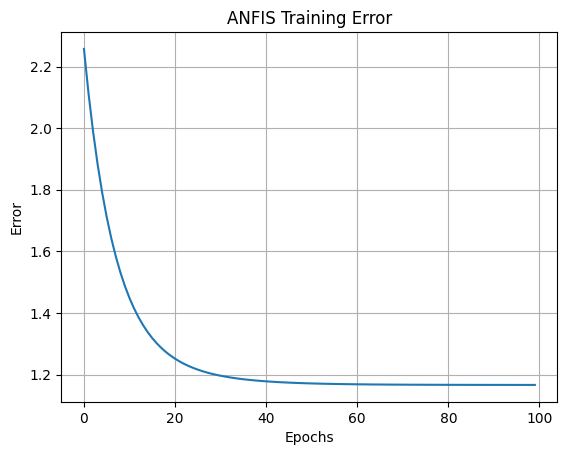

In [30]:
#9. Design of Adaptive Neuro-Fuzzy Inference System (ANFIS)


import numpy as np
import matplotlib.pyplot as plt
def gaussmf(x, c, sigma):
    return np.exp(-((x - c) ** 2) / (2 * sigma ** 2))

class ANFIS:
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        self.n = X.shape[0]
        self.c1, self.s1 = 0.0, 1.0
        self.c2, self.s2 = 1.0, 1.0
        self.p = np.random.rand(2)
        self.q = np.random.rand(2)
        self.r = np.random.rand(2)
        self.errors = []

    def train(self, epochs=100, lr=0.01):
        for _ in range(epochs):
            error_sum = 0
            for i in range(self.n):
                x1, x2 = self.X[i]
                y = self.Y[i]

                mu1 = gaussmf(x1, self.c1, self.s1)
                mu2 = gaussmf(x2, self.c2, self.s2)

                w1, w2 = mu1, mu2

                w1n = w1 / (w1 + w2)
                w2n = w2 / (w1 + w2)

                f1 = self.p[0]*x1 + self.q[0]*x2 + self.r[0]
                f2 = self.p[1]*x1 + self.q[1]*x2 + self.r[1]

                y_pred = w1n*f1 + w2n*f2

                error = y - y_pred
                error_sum += error**2

                self.p += lr * error
                self.q += lr * error
                self.r += lr * error

            self.errors.append(error_sum)

    def predict(self, X):
        out = []
        for x1, x2 in X:
            mu1 = gaussmf(x1, self.c1, self.s1)
            mu2 = gaussmf(x2, self.c2, self.s2)

            w1n = mu1 / (mu1 + mu2)
            w2n = mu2 / (mu1 + mu2)

            f1 = self.p[0]*x1 + self.q[0]*x2 + self.r[0]
            f2 = self.p[1]*x1 + self.q[1]*x2 + self.r[1]

            out.append(w1n*f1 + w2n*f2)

        return np.array(out)
X = np.array([
[0, 0],
[0, 1],
[1, 0],
[1, 1]
])
Y = np.array([0, 1, 1, 0])
model = ANFIS(X, Y)
model.train(epochs=100, lr=0.01)
print("Actual Output :", Y)
print("Predicted Output :", model.predict(X))
plt.plot(model.errors)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("ANFIS Training Error")
plt.grid()
plt.show()

In [31]:
#10. Comparison of Hard and Soft Computing Techniques

def hard_temperature(temp):
    if temp < 25:
        return "Cold"
    else:
        return "Hot"
def soft_temperature(temp):
    if temp <= 20:
        return "Cold"
    elif 20 < temp <= 30:
        return "Warm"
    else:
        return "Hot"
temperature = [18, 25, 28, 35]
print("Temperature | Hard Computing | Soft Computing")
print("---------------------------------------------")
for t in temperature:
    print(f"{t}°C         | {hard_temperature(t):13} | {soft_temperature(t)}")

Temperature | Hard Computing | Soft Computing
---------------------------------------------
18°C         | Cold          | Cold
25°C         | Hot           | Warm
28°C         | Hot           | Warm
35°C         | Hot           | Hot


In [32]:
#11. Implement PSO and use it to find the global minimum of the Rastrigin function

import numpy as np
def rastrigin(X):
    A = 10
    return A * len(X) + np.sum(X**2 - A * np.cos(2 * np.pi * X))
num_particles = 30
dimensions = 2
iterations = 100
w = 0.7
c1 = 1.5
c2 = 1.5
X = np.random.uniform(-5.12, 5.12, (num_particles, dimensions))
V = np.random.uniform(-1, 1, (num_particles, dimensions))
pbest = X.copy()
pbest_val = np.array([rastrigin(x) for x in X])
gbest = pbest[np.argmin(pbest_val)]
gbest_val = min(pbest_val)
for _ in range(iterations):
    for i in range(num_particles):
        r1, r2 = np.random.rand(), np.random.rand()
        V[i] = (w * V[i] +
        c1 * r1 * (pbest[i] - X[i]) +
        c2 * r2 * (gbest - X[i]))
        X[i] = X[i] + V[i]
        fitness = rastrigin(X[i])
        if fitness < pbest_val[i]:
            pbest[i] = X[i]
            pbest_val[i] = fitness
        gbest = pbest[np.argmin(pbest_val)]
        gbest_val = min(pbest_val)
print("Global Minimum Position:", gbest)
print("Minimum Value:", gbest_val)

Global Minimum Position: [-1.01464462e-06 -3.04261621e-09]
Minimum Value: 2.042490621079196e-10


In [33]:
#12. Use PSO to solve a simple load balancing problem: assign N independent tasks to M machines to minimize makespan.
import numpy as np
import random
N = 6
M = 3
task_time = np.array([2, 4, 6, 3, 5, 7])
num_particles = 20
iterations = 50
w, c1, c2 = 0.7, 1.5, 1.5
def fitness(position):
    loads = np.zeros(M)
    for i in range(N):
        machine = int(round(position[i])) % M
        loads[machine] += task_time[i]
    return max(loads)
particles = np.random.randint(0, M, (num_particles, N))
velocities = np.zeros((num_particles, N))
pbest = particles.copy()
pbest_fitness = np.array([fitness(p) for p in particles])
gbest = pbest[np.argmin(pbest_fitness)]
gbest_fitness = min(pbest_fitness)
for _ in range(iterations):
    for i in range(num_particles):
        r1, r2 = random.random(), random.random()
        velocities[i] = (w * velocities[i] +
        c1 * r1 * (pbest[i] - particles[i]) +
        c2 * r2 * (gbest - particles[i]))
        particles[i] = particles[i] + velocities[i]
        fit = fitness(particles[i])
        if fit < pbest_fitness[i]:
            pbest[i] = particles[i]
            pbest_fitness[i] = fit
        gbest = pbest[np.argmin(pbest_fitness)]
        gbest_fitness = min(pbest_fitness)
print("Best Task Allocation (task → machine):", np.round(gbest).astype(int))
print("Minimum Makespan:", gbest_fitness)

Best Task Allocation (task → machine): [0 1 0 2 1 2]
Minimum Makespan: 10.0


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0477
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0167
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0129
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0081
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0035
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0028
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0027
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0026
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0025
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0026
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0026
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0026
Epoch 16/20
63/63 

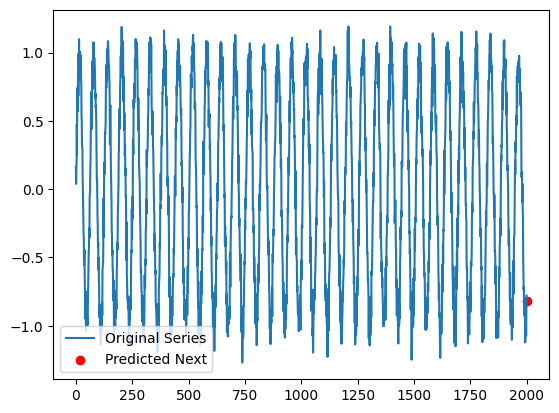

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Predicted next value: -0.65244037
Actual next value: -0.6086196629706776
Predicted next value: 0.3084538074996953


In [21]:
#13. Build and train an LSTM to predict the next value in a univariate time series (e.g.,
#daily sine wave + noise or stock-like synthetic series).
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
np.random.seed(1)
t = np.arange(0, 200, 0.1)
series = np.sin(t) + 0.1 * np.random.randn(len(t))
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1,1))
X, y = [], []
time_steps = 10
for i in range(len(series_scaled) - time_steps):
    X.append(series_scaled[i:i+time_steps])
    y.append(series_scaled[i+time_steps])
X = np.array(X)
y = np.array(y)
model = Sequential([
LSTM(50, activation='tanh', input_shape=(time_steps, 1)),
Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X, y, epochs=20, batch_size=32, verbose=1)
last_sequence = series_scaled[-time_steps:].reshape(1, time_steps, 1)
next_value_scaled = model.predict(last_sequence)
next_value = scaler.inverse_transform(next_value_scaled)
print("Predicted next value:", next_value[0][0])
plt.plot(series, label='Original Series')
plt.scatter(len(series), next_value[0][0], color='red', label='Predicted Next')
plt.legend()
plt.show()


#13 B
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
np.random.seed(1)
t = np.arange(0, 100, 0.1)
data = np.sin(t) + 0.1 * np.random.randn(len(t))
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1))
def create_sequences(data, step=10):
    X, y = [], []
    for i in range(len(data) - step):
        X.append(data[i:i+step, 0])
        y.append(data[i+step, 0])
    return np.array(X), np.array(y)
X, y = create_sequences(data, step=10)
X = X.reshape((X.shape[0], X.shape[1], 1))
model = Sequential()
model.add(LSTM(50, activation='tanh', input_shape=(10, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=20, batch_size=32, verbose=0)
predicted = model.predict(X[-1].reshape(1,10,1))
predicted_value = scaler.inverse_transform(predicted)
print("Predicted next value:", predicted_value[0][0])
#13 c)
import numpy as np
np.random.seed(1)
t = np.arange(0, 100, 0.1)
data = np.sin(t) + 0.1 * np.random.randn(len(t))
step = 10
X, y = [], []
for i in range(len(data) - step):
    X.append(data[i:i+step])
    y.append(data[i+step])
X = np.array(X)
y = np.array(y)
W = np.random.randn(step)
predictions = X @ W / step
print("Actual next value:", y[-1])
print("Predicted next value:", predictions[-1])

In [34]:
#14. Use an LSTM to perform sentiment classification on a small text dataset (use IMDB subset or synthetic dataset).
import torch
import torch.nn as nn
import torch.optim as optim
sentences = [
"I love this movie",
"This film is great",
"Amazing experience",
"I hate this movie",
"This film is terrible",
"Worst experience"
]
labels = [1, 1, 1, 0, 0, 0]
vocab = {}
for s in sentences:
    for w in s.lower().split():
        if w not in vocab:
            vocab[w] = len(vocab) + 1
def encode(sentence):
    return [vocab.get(w, 0) for w in sentence.lower().split()]
X = [encode(s) for s in sentences]
y = torch.tensor(labels, dtype=torch.float)
max_len = max(len(seq) for seq in X)
X_pad = [seq + [0]*(max_len - len(seq)) for seq in X]
X_tensor = torch.tensor(X_pad)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size + 1, 8, padding_idx=0)
        self.lstm = nn.LSTM(8, 16, batch_first=True)
        self.fc = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.embed(x)
        _, (h, _) = self.lstm(x)
        return self.sigmoid(self.fc(h[-1]))
model = LSTMClassifier(len(vocab))
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
for epoch in range(200):
    optimizer.zero_grad()
    output = model(X_tensor).squeeze()
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
test_sentence = "I love this film"
test_encoded = encode(test_sentence)
test_encoded += [0] * (max_len - len(test_encoded))
test_tensor = torch.tensor([test_encoded])
prediction = model(test_tensor).item()
print("Sentiment score (0=negative, 1=positive):", prediction)

Sentiment score (0=negative, 1=positive): 0.999526858329773


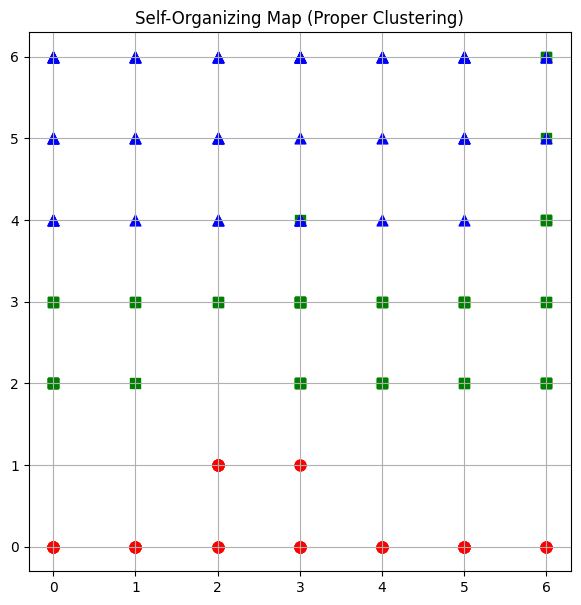

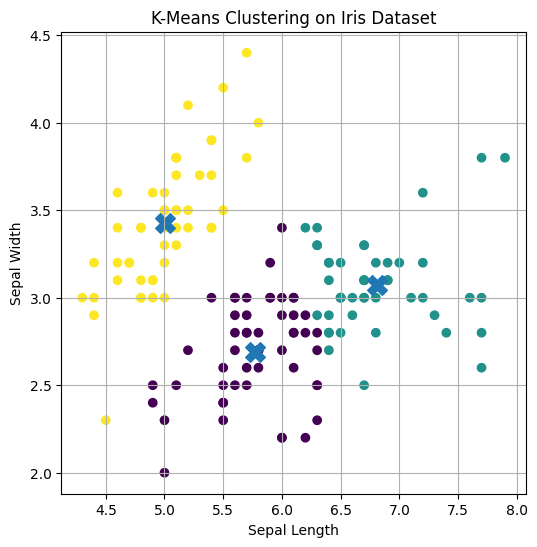

In [35]:
#15. Implement SOM and use it for clustering and visualization of the Iris dataset (or high-dimensional synthetic data).
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
m, n = 7, 7
input_len = X.shape[1]
weights = np.random.random((m, n, input_len))
epochs = 1000
initial_lr = 0.6
initial_radius = max(m, n) / 2
for epoch in range(epochs):
    lr = initial_lr * np.exp(-epoch / epochs)
    radius = initial_radius * np.exp(-epoch / epochs)
    for sample in X:
        dist = np.linalg.norm(weights - sample, axis=2)
        bmu_x, bmu_y = np.unravel_index(np.argmin(dist), dist.shape)
        for i in range(m):
            for j in range(n):
                d = np.sqrt((i - bmu_x)**2 + (j - bmu_y)**2)
                if d <= radius:
                    influence = np.exp(-(d**2) / (2 * (radius**2)))
                    weights[i, j] += lr * influence * (sample - weights[i, j])
plt.figure(figsize=(7,7))
markers = ['o', 's', '^']
colors = ['red', 'green', 'blue']
for i, sample in enumerate(X):
    dist = np.linalg.norm(weights - sample, axis=2)
    bmu_x, bmu_y = np.unravel_index(np.argmin(dist), dist.shape)
    plt.scatter(bmu_x, bmu_y,
    c=colors[y[i]],
    marker=markers[y[i]],
    s=60)
plt.title("Self-Organizing Map (Proper Clustering)")
plt.grid()
plt.show()


#15 B

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
iris = load_iris()
X = iris.data
y = iris.target
X_vis = X[:, :2]
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X_vis)
plt.figure(figsize=(6,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:,0],
kmeans.cluster_centers_[:,1],
marker='X', s=200)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering on Iris Dataset")
plt.grid()
plt.show()

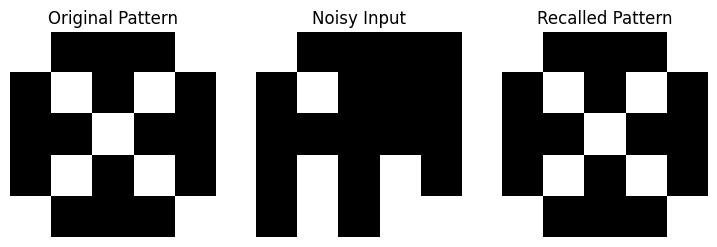

In [38]:
#16. Implement a Hopfield network to store and recall binary patterns; demonstrate recall from noisy inputs.
import numpy as np
import matplotlib.pyplot as plt
def to_bipolar(pattern):
    return np.where(pattern == 0, -1, 1)

class HopfieldNetwork:
    def __init__(self, num_neurons):
        self.num_neurons = num_neurons
        self.weights = np.zeros((num_neurons, num_neurons))
    def train(self, patterns):
        for p in patterns:
            self.weights += np.outer(p, p)
        np.fill_diagonal(self.weights, 0)
        self.weights /= len(patterns)
    def recall(self, pattern, steps=10):
        s = pattern.copy()
        for _ in range(steps):
            for i in range(self.num_neurons):
                net_input = np.dot(self.weights[i], s)
                s[i] = 1 if net_input >= 0 else -1
        return s
patterns = [
np.array([
1,0,0,0,1,
0,1,0,1,0,
0,0,1,0,0,
0,1,0,1,0,
1,0,0,0,1
]),
np.array([
0,1,1,1,0,
1,0,0,0,1,
1,0,0,0,1,
1,0,0,0,1,
0,1,1,1,0
])
]
patterns = [to_bipolar(p) for p in patterns]
hopfield = HopfieldNetwork(num_neurons=25)
hopfield.train(patterns)
noisy_pattern = patterns[0].copy()
noise_indices = np.random.choice(25, 6, replace=False)
noisy_pattern[noise_indices] *= -1
recalled_pattern = hopfield.recall(noisy_pattern)
def plot_pattern(pattern, title, pos):
    plt.subplot(1, 3, pos)
    plt.imshow(pattern.reshape(5,5), cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.figure(figsize=(9,3))
plot_pattern(patterns[0], "Original Pattern", 1)
plot_pattern(noisy_pattern, "Noisy Input", 2)
plot_pattern(recalled_pattern, "Recalled Pattern", 3)
plt.show()

In [37]:
#17. Implement a Hopfield network to store and recall binary patterns; demonstrate recall from noisy inputs.
import numpy as np
A = np.array([
[ 1, -1,  1, -1],
[-1,  1, -1,  1],
[ 1,  1, -1, -1]
])
B = np.array([
[ 1, -1, -1],
[-1,  1, -1],
[-1, -1,  1]
])
W = np.zeros((A.shape[1], B.shape[1]))
for i in range(len(A)):
    W += np.outer(A[i], B[i])
print("Weight Matrix W:\n", W)
A_noisy = np.array([1, -1, -1, -1])
B_recalled = np.sign(A_noisy @ W)
B_recalled[B_recalled == 0] = 1
print("\nNoisy Input A:", A_noisy)
print("Recalled Output B:", B_recalled)
A_recalled = np.sign(B_recalled @ W.T)
A_recalled[A_recalled == 0] = 1
print("Recalled Input A:", A_recalled)

Weight Matrix W:
 [[ 1. -3.  1.]
 [-3.  1.  1.]
 [ 3. -1. -1.]
 [-1.  3. -1.]]

Noisy Input A: [ 1 -1 -1 -1]
Recalled Output B: [ 1. -1.  1.]
Recalled Input A: [ 1. -1.  1. -1.]
